In [2]:
import itertools
import time
from typing import TypeAlias, Any, Callable, ParamSpec, Concatenate
from collections.abc import Sequence

import numpy as np
import numpy.random as npr
import numpy.typing as npt

from scipy import integrate as intg
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import matplotlib.cm as cm

import pynumdiff as ndiff  # Some submodules requrie cvxpy or tqdm
from pynumdiff import smooth_finite_difference as smoothfd
from pynumdiff import polynomial_fit as polyfit
from pynumdiff import basis_fit as basisfit
from pynumdiff import optimize as ndiffopt
from pynumdiff.utils import evaluate as ndiffeval
import pysindy as ps
import sys

import importlib
import mysindy
import systems

importlib.reload(mysindy)  # Force reloading module to apply changes
importlib.reload(systems)

<module 'systems' from '/Users/alexeagan/SINDy/SINDY-Noise-Investigation/systems.py'>

In [ ]:
dt = 1e-2
num_steps = 3 * 10**4

x_0 = np.array([0, 2, 8])
traj = systems.Trajectory(
    mysindy.lorenz, x_0, dt, num_steps, 1, butterworth_cutoff=0.02
)

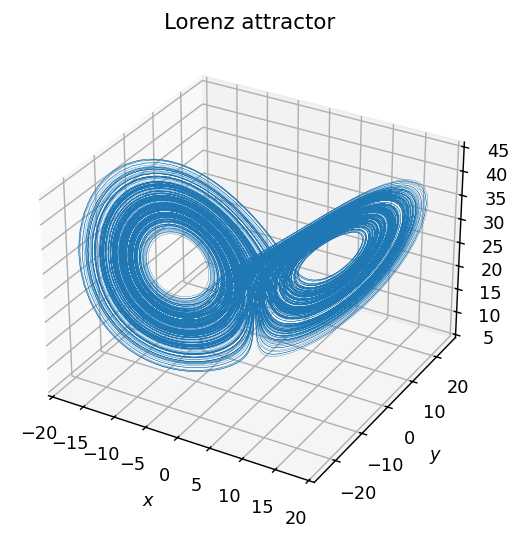

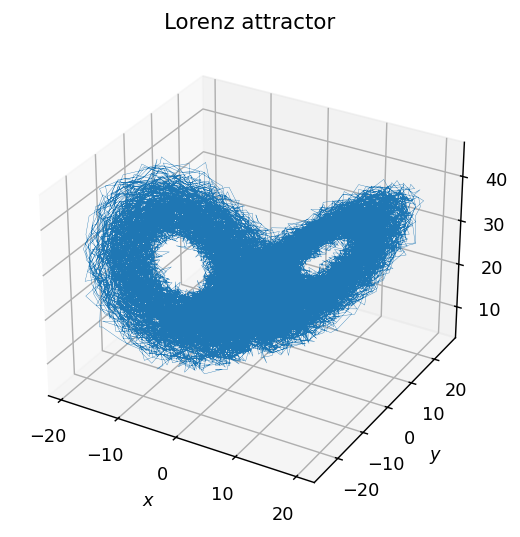

In [6]:
ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x, lw=0.2)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x_noisy, lw=0.2)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

# Optimization of denoising hyperparameter


## How to interpret RMSE and $R^2$

From the Komarov, Kutz paper:

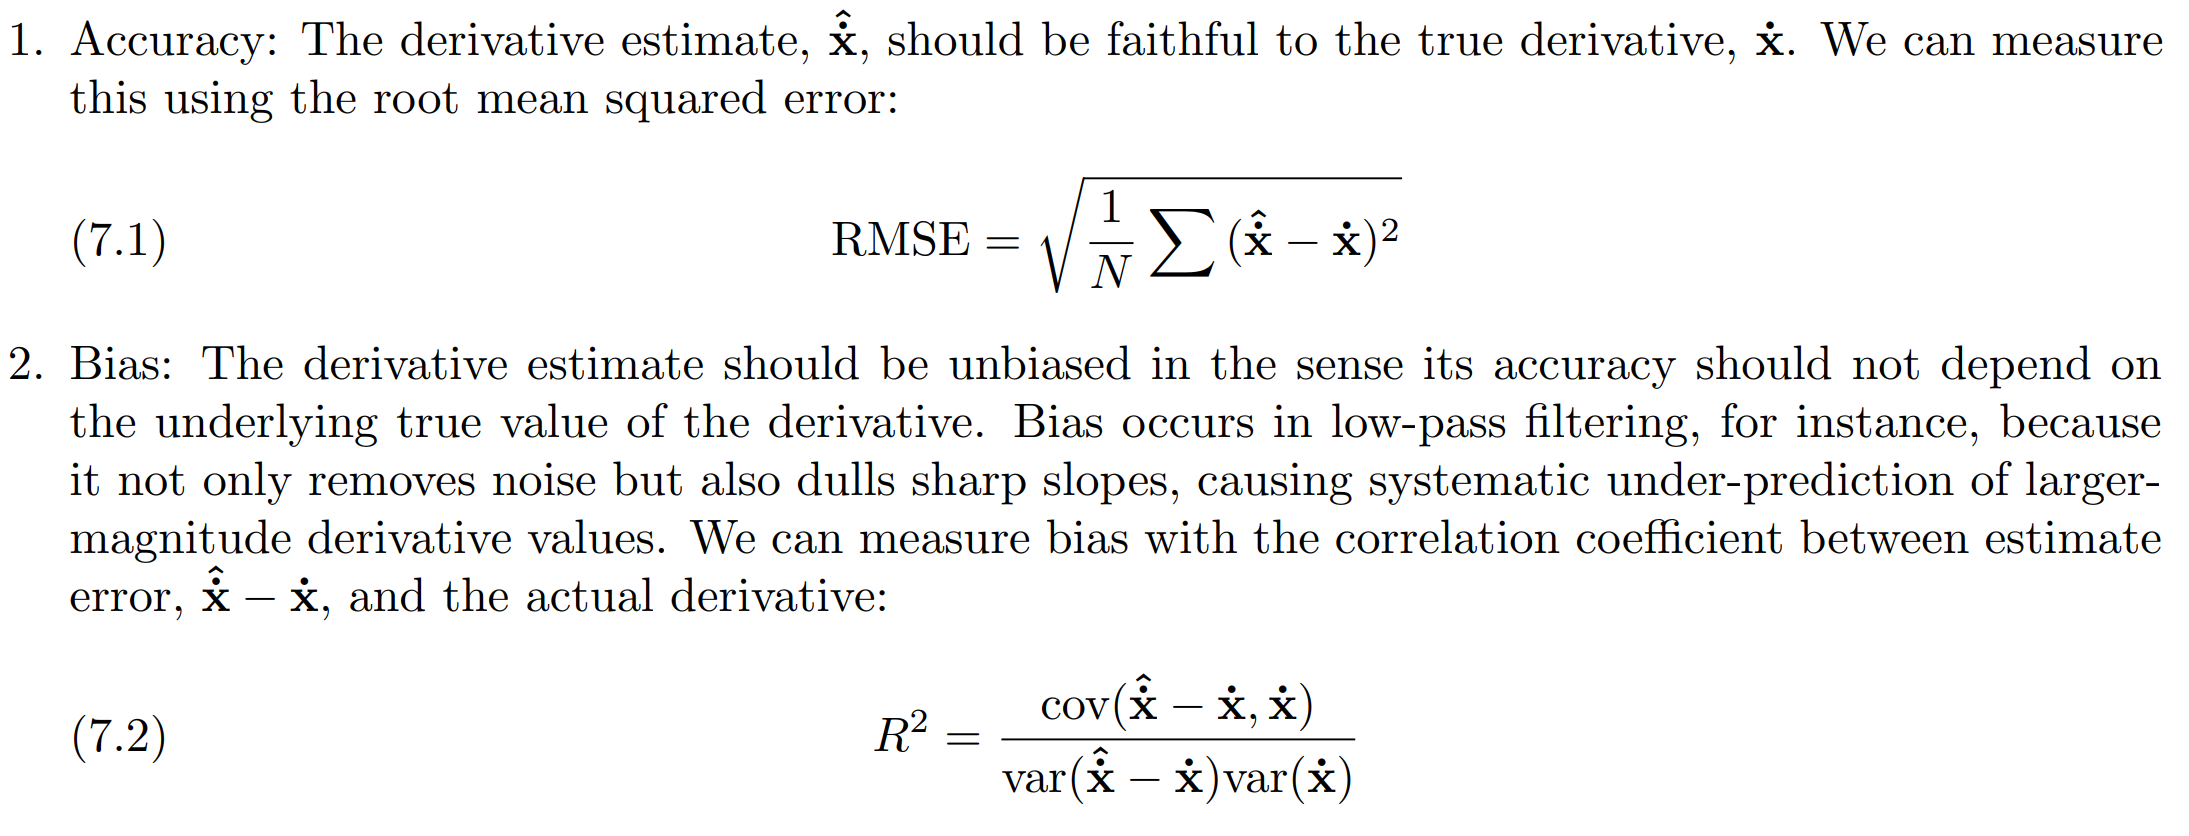

## Estimate $\gamma$

The code is given by [2_optimizing_hyperparameters.ipynb](./pynumdiff%20documentation/2_optimizing_hyperparameters.ipynb).


### Cutoff frequency

Cutoff frequency is an estimation of the upper limit of data signal frequency. To choose it, we perform FFT on $z$, which is given by `traj.x_noisy[2]`.


In [ ]:
z = traj.x_noisy[2]
z_fft = np.fft.fft(z)
energy_db = 20 * np.log10(np.abs(z_fft))
freqs = np.fft.fftfreq(len(z_fft), dt)
energy_db = energy_db[freqs >= 0]
freqs = freqs[freqs >= 0]

plt.figure(figsize=(15, 3))
plt.semilogx(freqs, energy_db, linewidth=0.5)
plt.title("Power Spectrum of Simulated Data", fontsize=14)
plt.xlabel("Frequency in Hz", fontsize=12)
plt.ylabel("Relative Magnitude in dB", fontsize=12)
plt.show()

Zoom in to $1\text{--}10\,\text{Hz}$:


In [ ]:
plt.figure(figsize=(15, 3))
freq_plot_range = (1 <= freqs) & (freqs <= 10)
plt.semilogx(freqs[freq_plot_range], energy_db[freq_plot_range], linewidth=0.5)
plt.title("Power Spectrum of Simulated Data", fontsize=14)
plt.xlabel("Frequency in Hz", fontsize=12)
plt.ylabel("Relative Magnitude in dB", fontsize=12)

ticks = np.arange(1, 11)
plt.xticks(ticks=ticks, labels=[str(tick) for tick in ticks])
plt.grid(True)
plt.show()

From this plot, we see that $3\,\text{Hz}$ is a good cutoff frequency.


### Heuristic formula for $\gamma$

$$ \ln\gamma = -1.6 \ln f - 0.71 \ln \Delta t - 5.1 $$

#### Reference

F. van Breugel, B. W. Brunton, and J. N. Kutz. Numerical differentiation of noisy data: A unifying multi-objective optimization framework. *IEEE Access,* 2020.

In [ ]:
def estimate_gamma(cutoff_freq, dt):
    log_gamma = -1.6 * np.log(cutoff_freq) - 0.71 * np.log(dt) - 5.1
    gamma = np.exp(log_gamma)
    return gamma

cutoff_freq = 3
gamma = estimate_gamma(cutoff_freq, dt)
print(f"gamma = {gamma}")

## Optimization of several denoising methods

Since performing optimization on the whole dataset is time consuming, and we assume the shape of noise is consistent, we use the first 3000 data points for optimization.

In [ ]:
def optimize_hparams(method, data_noisy, num_steps_opt, dt, gamma):
    data_sample = data_noisy[0:num_steps_opt]

    tic = time.perf_counter()
    hparams, loss = ndiffopt.optimize(
        method, data_sample, dt, tvgamma=gamma, metric="rmse"
    )
    toc = time.perf_counter() - tic
    print(method.__name__)
    print("---")
    print(f"Optimization run time: {toc:.4g} s")
    print("---")

    print("Optimal parameters:")
    [print(f"{key}: {value}") for key, value in hparams.items()]
    print()

    data_denoised, data_diff_denoised = method(data_noisy, dt, **hparams)

    return hparams, data_denoised, data_diff_denoised, toc


def compare_denoised_to_truth(
    method, ax, num_steps_plot, t_arr, data_truth, data_denoised
):
    t_plot = t_arr[0:num_steps_plot]
    data_truth_plot = data_truth[0:num_steps_plot]
    data_denoised_plot = data_denoised[0:num_steps_plot]

    rmse = ndiffeval.rmse(data_truth, data_denoised)
    err_corr = ndiffeval.error_correlation(data_truth, data_denoised)
    rmse_str = f"{rmse:.4g}"
    err_corr_str = f"{err_corr:.4g}"

    (line_denoised,) = ax.plot(t_plot, data_denoised_plot, linewidth=1)
    line_denoised.set_label("Denoised")
    (line_truth,) = ax.plot(t_plot, data_truth_plot, linewidth=1)
    line_truth.set_label("Ground truth")
    line_denoised.set_zorder(line_truth.get_zorder() + 0.1)
    ax.legend()
    ax.set_title(f"{method.__name__}, RMSE = {rmse_str}, $R^2$ = {err_corr_str}")

    return rmse, err_corr


def optimize_and_plot(
    method, ax, traj: systems.Trajectory, num_steps_opt, num_steps_plot, gamma
):
    t_arr = traj.t_arr
    z_dot = traj.x_dot[2]
    z_noisy = traj.x_noisy[2]

    hparams, z_denoised, z_dot_denoised, toc = optimize_hparams(
        method, z_noisy, num_steps_opt, dt, gamma
    )
    rmse, err_corr = compare_denoised_to_truth(
        method, ax, num_steps_plot, t_arr, z_dot, z_dot_denoised
    )

    return hparams, toc, rmse, err_corr, z_denoised, z_dot_denoised

In [ ]:
num_steps_opt = 3000
num_steps_plot = 1000

methods = {
    smoothfd.kerneldiff: "Kernel smoothing",
    smoothfd.butterdiff: "Butterworth smoothing",
    smoothfd.finitediff: "Iterated finite difference",
    polyfit.polydiff: "Sliding polynomial fit",
    polyfit.savgoldiff: "Savitzky-Golay filter",
    basisfit.spectraldiff: "Spectral derivative with tricks",
    basisfit.rbfdiff: "Radial basis functions"
}
num_methods = len(methods)
optimization_args = (traj, num_steps_opt, num_steps_plot, gamma)

In [ ]:
fig = plt.figure(figsize=(8, 2.5 * num_methods))
axs = fig.subplots(nrows=num_methods)
fig.subplots_adjust(hspace=0.4)

results = {
    method.__name__: optimize_and_plot(method, ax, *optimization_args)[:4]
    for method, ax in zip(methods.keys(), axs)
}

In [ ]:
fig, ax = plt.subplots()

times = [results[method][1] for method in results.keys()]
norm = clr.Normalize(min(times), max(times))

for method, (param_dict, time, err, err_corr) in results.items():
    ax.scatter(err_corr, err, None, time, norm=norm, cmap="viridis")
    ax.annotate(
        method,
        (err_corr, err),
        xytext=(5, -1 if method == "spectraldiff" else 3),
        textcoords="offset points",
    )

ax.set_xscale("log")
ax.set_xlabel("$R^2$")
ax.set_ylabel("RMSE")

sm = cm.ScalarMappable(cmap="viridis", norm=norm)
fig.colorbar(sm, ax=ax, label="run time (s)")

x_min, x_max = ax.get_xlim()
margin = np.log10(x_max / x_min) * 0.2
ax.set_xlim(x_min, x_max * 10**margin)

y_min, y_max = ax.get_ylim()
margin = (y_max - y_min) * 0.03
ax.set_ylim(y_min, y_max + margin)

plt.show()

In [46]:
noise_levels = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1, 1.5, 3, 5] #noise levels to test

#Parameters for the system and data generation
dt = 1e-3
num_steps = 2 * 10 ** 5
x_0 = np.array([0, 2, 8])


In [47]:
#Setting up pysindy
sparsity_threshold = 0.05
stlsq_optimizer = ps.STLSQ(threshold=sparsity_threshold, alpha=0.05) # alpha can be used for additional regularization

# Initialize the SINDy model with the configured optimizer
model = ps.SINDy(optimizer=stlsq_optimizer)

# Define the polynomial library with degree 3
poly_library = ps.PolynomialLibrary(degree=2)

In [48]:
#Calculate MSE for each noise level using pySINDy
SEs_zterms = []
MSEs = []
XIs = []
for i, noise in enumerate(noise_levels):
    traj = systems.Trajectory(mysindy.lorenz, x_0, dt, num_steps, noise)
    #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working

    #Initialize sindy model with polynomial 3
    model_poly3 = ps.SINDy(
      optimizer=stlsq_optimizer,
      feature_library=poly_library
      )
    model_poly3.fit(traj.x_noisy.transpose(), t=dt)
    # Call model.coefficients() to get the coefficient matrix
    xi = model_poly3.coefficients()
    XIs.append(xi)

    #This is the end of where our sindy implementation differs
    
    lorenz_arr_padded = mysindy.lorenz_array(xi.transpose())
    #print(xi.transpose().shape)
    #print(lorenz_arr_padded.shape)
    MSEs.append(mean_squared_error(xi.transpose(), lorenz_arr_padded))

    mask = (xi.transpose() != 0) & (lorenz_arr_padded == 0)
    SEs_zterms.append(np.sum(np.sqrt((xi.transpose()[mask]-lorenz_arr_padded[mask])**2)))


term_nums = [np.count_nonzero(xi) for xi in XIs]
print(SEs_zterms)

[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.5169682315184277), np.float64(1.1190565911236163), np.float64(5.841659454854764), np.float64(11.414234497228389), np.float64(30.816264974360625), np.float64(39.966782532959435)]


In [49]:
#Setting up our SINDy
threshold = sparsity_threshold # sparsification knob lambda

In [50]:
#Calculate MSE for each noise level using our SINDy
SEs_zterms_ours = []
MSEs_ours = []
XIs_ours = []
for i, noise in enumerate(noise_levels):
    traj = systems.Trajectory(mysindy.lorenz, x_0, dt, num_steps, noise)
    #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working
    lib = mysindy.library_function(traj.x_noisy.transpose(), 2, df=False)
    sol = mysindy.stls(lib, traj.x_dot_denoised.transpose(), threshold)


    XIs_ours.append(sol)
    #print(sol)
    #This is the end of where our sindy implementation differs
    
    lorenz_arr_padded = mysindy.lorenz_array(sol)

    #print(xi.transpose().shape)
    #print(lorenz_arr_padded.shape)
    MSEs_ours.append(mean_squared_error(sol, lorenz_arr_padded))

    mask = (sol != 0) & (lorenz_arr_padded == 0)
    SEs_zterms_ours.append(np.sum(np.sqrt((sol[mask]-lorenz_arr_padded[mask])**2)))
term_nums_ours = [np.count_nonzero(xi) for xi in XIs_ours]

Exited at 1 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 3 iterations.
Exited at 3 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.


[0.001469509358306758, 0.0014876214777681206, 0.0017288232160893513, 0.0025024528665878003, 0.006825650278377075, 0.2738882639815224, 0.04250642607427423, 2.2867156032311837, 4.937356834549949, 8.859824700642216, 17.92381740883191, 38.25554833762899, 49.7132867790734]
[8.47914539547791e-28, 0.0015845423039719418, 0.0018081170310504018, 0.002521953559428885, 0.00641368599607654, 0.016533549447718884, 0.03786072319876944, 2.118618459757064, 5.156202908842797, 8.33366536886305, 16.869283267091276, 32.021228443672015, 39.923800697318605]


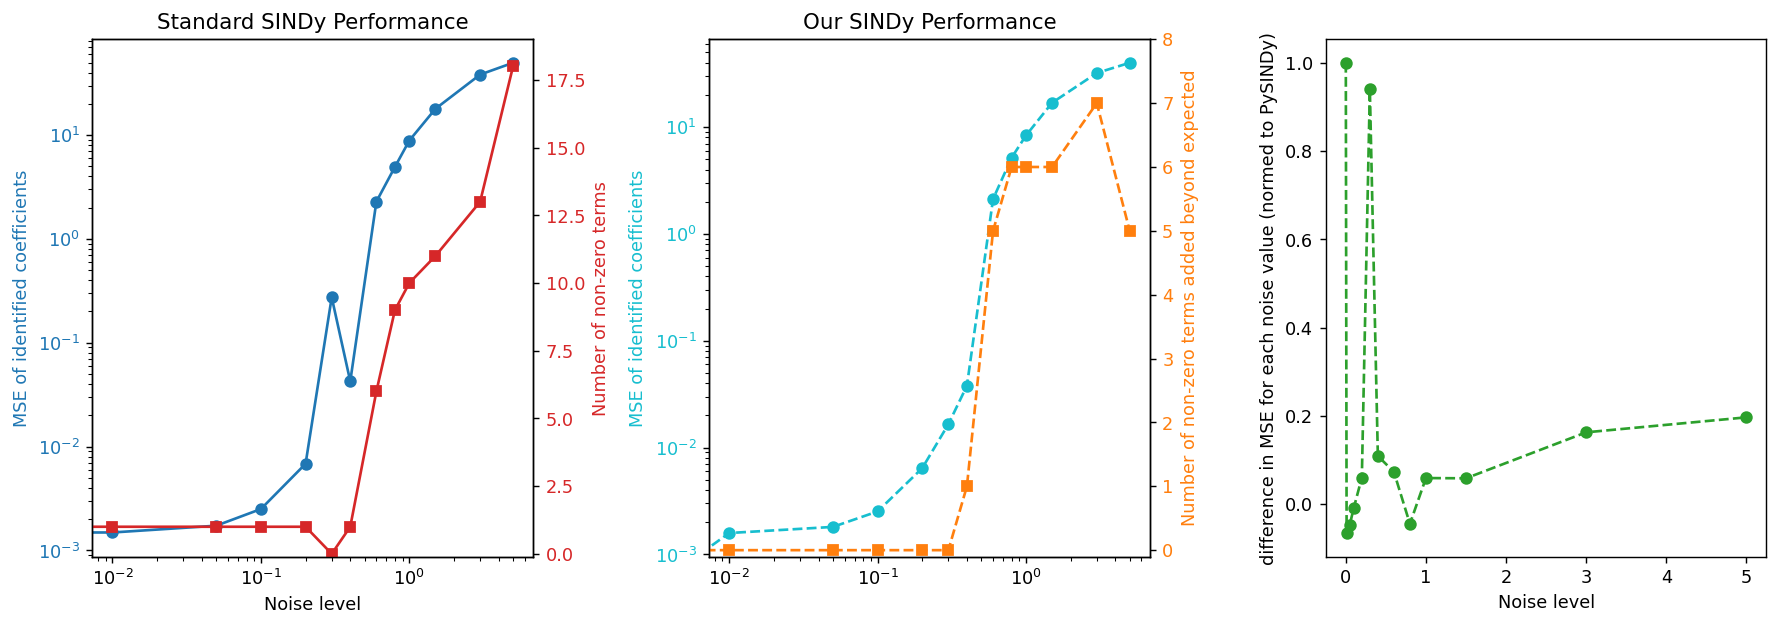

In [51]:
import matplotlib
logy = True
logx = True
sparsity = True

# 1. Create a figure with two subplots side-by-side
fig, (ax_orig, ax_ours, ax_diff) = plt.subplots(1, 3, figsize=(14, 5), dpi=128)

# --- LEFT PLOT: Original SINDy ---
# MSE on left y-axis
ax_orig.plot(noise_levels, MSEs, marker="o", color="tab:blue", label="MSE")
ax_orig.set_xlabel("Noise level")
ax_orig.set_ylabel("MSE of identified coefficients", color="tab:blue")
ax_orig.tick_params(axis='y', labelcolor="tab:blue")
ax_orig.set_title("Standard SINDy Performance")
if logx:
    ax_orig.set_xscale('log')
if logy:
    ax_orig.set_yscale('log')

print(MSEs)
if sparsity:
    # Sparsity on right y-axis
    ax_orig_2 = ax_orig.twinx()
    ax_orig_2.plot(noise_levels, term_nums-min(term_nums), marker="s", color="tab:red", label="Non-zero terms")
    ax_orig_2.set_ylabel("Number of non-zero terms", color="tab:red")
    ax_orig_2.tick_params(axis='y', labelcolor="tab:red")
    ax_orig_2.set_ylim(-0.1, max(term_nums)-min(term_nums) + 1)
    if logx:
        ax_orig_2.set_xscale('log')

# --- RIGHT PLOT: Our SINDy ---
# MSE on left y-axis
print(MSEs_ours)
ax_ours.plot(noise_levels, np.array(MSEs_ours).round(7), marker="o", color="tab:cyan", ls="--", label="MSE (Ours)")

ax_ours.set_ylabel("MSE of identified coefficients", color="tab:cyan")
ax_ours.tick_params(axis='y', labelcolor="tab:cyan")
ax_ours.set_title("Our SINDy Performance")
if logx:
    ax_ours.set_xscale('log')
if logy:
    ax_ours.set_yscale('log')

if sparsity:
    # Sparsity on right y-axis
    ax_ours_2 = ax_ours.twinx()
    ax_ours_2.plot(noise_levels, term_nums_ours-min(term_nums_ours), marker="s", color="tab:orange", ls="--", label="Non-zero terms added (Ours)")
    ax_ours_2.set_ylabel("Number of non-zero terms added beyond expected", color="tab:orange")
    ax_ours_2.tick_params(axis='y', labelcolor="tab:orange")
    ax_ours_2.set_ylim(-0.1, max(term_nums_ours)-min(term_nums_ours) + 1)
    if logx:
        ax_ours_2.set_xscale('log')


#Plot difference#
diff = (MSEs - np.array(MSEs_ours).round(7))/MSEs
ax_diff.plot(noise_levels, diff, marker="o", color="tab:green", ls="--", label ="Difference between MSEs")
ax_diff.set_ylabel("difference in MSE for each noise value (normed to PySINDy)")
ax_diff.set_xlabel("Noise level")
# 4. Final formatting
fig.tight_layout() 
plt.show()



[0.001469509358306758, 0.0014876214777681206, 0.0017288232160893513, 0.0025024528665878003, 0.006825650278377075, 0.2738882639815224, 0.04250642607427423, 2.2867156032311837, 4.937356834549949, 8.859824700642216, 17.92381740883191, 38.25554833762899, 49.7132867790734]
[0.00000000e+00 1.58450000e-03 1.80810000e-03 2.52200000e-03
 6.41370000e-03 1.65335000e-02 3.78607000e-02 2.11861850e+00
 5.15620290e+00 8.33366540e+00 1.68692833e+01 3.20212284e+01
 3.99238007e+01]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.5169682315184277), np.float64(1.1190565911236163), np.float64(5.841659454854764), np.float64(11.414234497228389), np.float64(30.816264974360625), np.float64(39.966782532959435)]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.08556624000013359), np.float64(0.5790000121229044), np.float64(4.697924073184022), np.float64(5.61097373

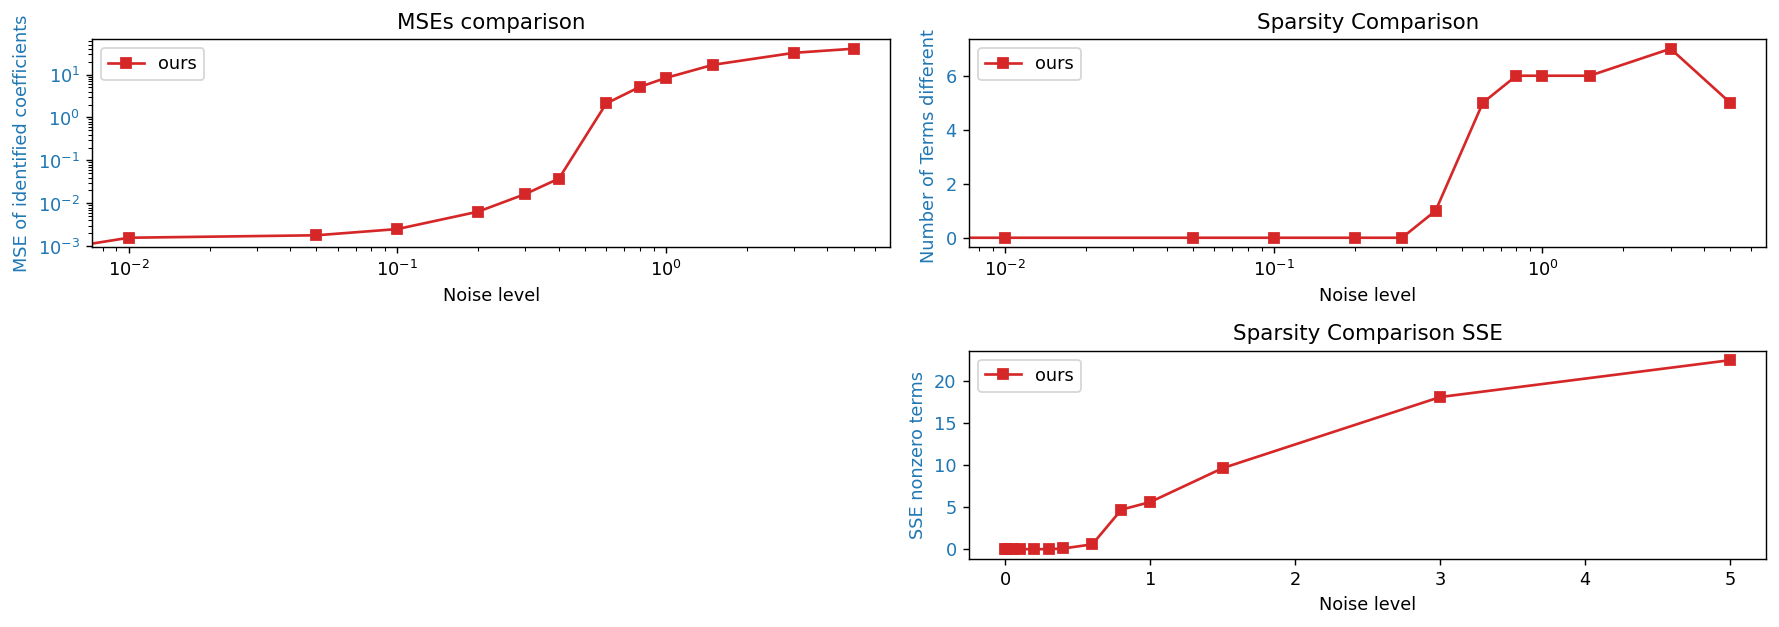

In [52]:
logy = True
logx = True
sparsity = True
PySINDy = False

# 1. Create a figure with two subplots side-by-side
fig, ((ax_MSEs, ax_sparsity), (ax_diff_MSEs, ax_SSE)) = plt.subplots(2, 2, figsize=(14, 5), dpi=128)

MSEs_ours = np.array(MSEs_ours).round(7)
# --- LEFT PLOT: Original SINDy ---
# MSE on left y-axis
if PySINDy:
    ax_MSEs.plot(noise_levels, MSEs, marker="o", color="tab:blue", label="PySINDY")
ax_MSEs.plot(noise_levels, MSEs_ours, marker="s", color="tab:red", label="ours")
ax_MSEs.set_xlabel("Noise level")
ax_MSEs.set_ylabel("MSE of identified coefficients", color="tab:blue")
ax_MSEs.tick_params(axis='y', labelcolor="tab:blue")
ax_MSEs.set_title("MSEs comparison")
if logx:
    ax_MSEs.set_xscale('log')
if logy:
    ax_MSEs.set_yscale('log')
ax_MSEs.legend()

print(MSEs)
# --- RIGHT PLOT: Our SINDy ---
# MSE on left y-axis
print(MSEs_ours)
if PySINDy:  
    ax_sparsity.plot(noise_levels, np.array(term_nums)-7, marker="o", color="tab:blue", label="PySINDY")
ax_sparsity.plot(noise_levels, np.array(term_nums_ours)-7, marker="s", color="tab:red", label="ours")
ax_sparsity.set_xlabel("Noise level")
ax_sparsity.set_ylabel("Number of Terms different ", color="tab:blue")
ax_sparsity.tick_params(axis='y', labelcolor="tab:blue")
ax_sparsity.set_title("Sparsity Comparison")
if logx:
    ax_sparsity.set_xscale('log')
ax_sparsity.legend()


if PySINDy: 
#Plot difference#
    diff = (MSEs - np.array(MSEs_ours).round(7))/MSEs *100
    ax_diff_MSEs.plot(noise_levels[1:], diff[1:], marker="o", color="tab:green", ls="--", label ="Difference between MSEs")
    ax_diff_MSEs.set_ylabel("Difference in MSEs \n(normed to PySINDy)")
    ax_diff_MSEs.set_xlabel("Noise level")
    ax_diff_MSEs.legend()
else:
    ax_diff_MSEs.set_visible(False)


# --- RIGHT PLOT bottom SSE --
# -
if PySINDy: 
    ax_SSE.plot(noise_levels, SEs_zterms, marker="o", color="tab:blue", label="PySINDY")
print(SEs_zterms)
print(SEs_zterms_ours)
ax_SSE.plot(noise_levels, SEs_zterms_ours, marker="s", color="tab:red", label="ours")
ax_SSE.set_xlabel("Noise level")
ax_SSE.set_ylabel("SSE nonzero terms", color="tab:blue")
ax_SSE.tick_params(axis='y', labelcolor="tab:blue")
ax_SSE.set_title("Sparsity Comparison SSE")
ax_SSE.legend()



# 4. Final formatting
fig.tight_layout() 
plt.show()



Sparsity and Data Quantitiy

In [14]:
noise_levels = [.5] #noise levels to test

#Parameters for the system and data generation
dt = 1e-3
num_steps_lst = np.logspace(3.5, 6, 10).astype(int)
x_0 = np.array([0, 2, 8])

threshold = 0.2 # sparsification knob lambda

#Setting up pysindy
sparsity_threshold = threshold
stlsq_optimizer = ps.STLSQ(threshold=sparsity_threshold, alpha=0.05) # alpha can be used for additional regularization

# Initialize the SINDy model with the configured optimizer
model = ps.SINDy(optimizer=stlsq_optimizer)

# Define the polynomial library with degree 3
poly_library = ps.PolynomialLibrary(degree=2)


MSEs_ours_steps = []
SEs_zterms_ours_steps = []
term_nums_ours_steps = []

MSEs_pys_steps = []
SEs_zterms_pys_steps = []
term_nums_pys_steps = []
for num_steps in num_steps_lst:
    #Calculate MSE for each noise level using our SINDy
    SEs_zterms_ours = []
    MSEs_ours = []
    XIs_ours = []
    for i, noise in enumerate(noise_levels):
        traj = systems.Trajectory(mysindy.lorenz, x_0, dt, num_steps.round(), noise)
        
        #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working
        lib = mysindy.library_function(traj.x_noisy.transpose(), 2, df=False)
        sol = mysindy.stls(lib, traj.x_dot_denoised.transpose(), threshold)
        XIs_ours.append(sol)
        #This is the end of where our sindy implementation differs
        #print(f"solve:{sol}")
        #print(sol.shape)
        
        lorenz_arr_padded = mysindy.lorenz_array(sol)

        MSEs_ours.append(mean_squared_error(sol, lorenz_arr_padded))

        mask = (sol != 0) & (lorenz_arr_padded == 0)
        SEs_zterms_ours.append(np.sum(np.sqrt((sol[mask]-lorenz_arr_padded[mask])**2)))
    term_nums_ours = [np.count_nonzero(xi) for xi in XIs_ours]
    #print(SEs_zterms_ours)

    MSEs_ours_steps.append(MSEs_ours)
    SEs_zterms_ours_steps.append(SEs_zterms_ours)
    term_nums_ours_steps.append(term_nums_ours)




    #Calculate MSE for each noise level using pySINDy
    SEs_zterms = []
    MSEs = []
    XIs = []
    for i, noise in enumerate(noise_levels):
        traj = systems.Trajectory(mysindy.lorenz, x_0, dt, num_steps.round(), noise)
        
        #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working
        model_poly3 = ps.SINDy(
        optimizer=stlsq_optimizer,
        feature_library=poly_library
        )
        model_poly3.fit(traj.x_noisy.transpose(), t=dt)
        xi_pys = model_poly3.coefficients()
        XIs.append(xi_pys)
        #This is the end of where our sindy implementation differs
        #print(xi_pys.shape)
        
        lorenz_arr_padded = mysindy.lorenz_array(xi_pys.transpose())
        #print(xi.transpose().shape)
        #print(lorenz_arr_padded.shape)
        MSEs.append(mean_squared_error(xi_pys.transpose(), lorenz_arr_padded))

        mask = (xi_pys.transpose() != 0) & (lorenz_arr_padded == 0)
        SEs_zterms.append(np.sum(np.sqrt((xi_pys.transpose()[mask]-lorenz_arr_padded[mask])**2)))


    term_nums = [np.count_nonzero(xi) for xi in XIs]
    #print(SEs_zterms)
    MSEs_pys_steps.append(MSEs)
    SEs_zterms_pys_steps.append(SEs_zterms)
    term_nums_pys_steps.append(term_nums)



Exited at 3 iterations.
Exited at 3 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.
Exited at 2 iterations.


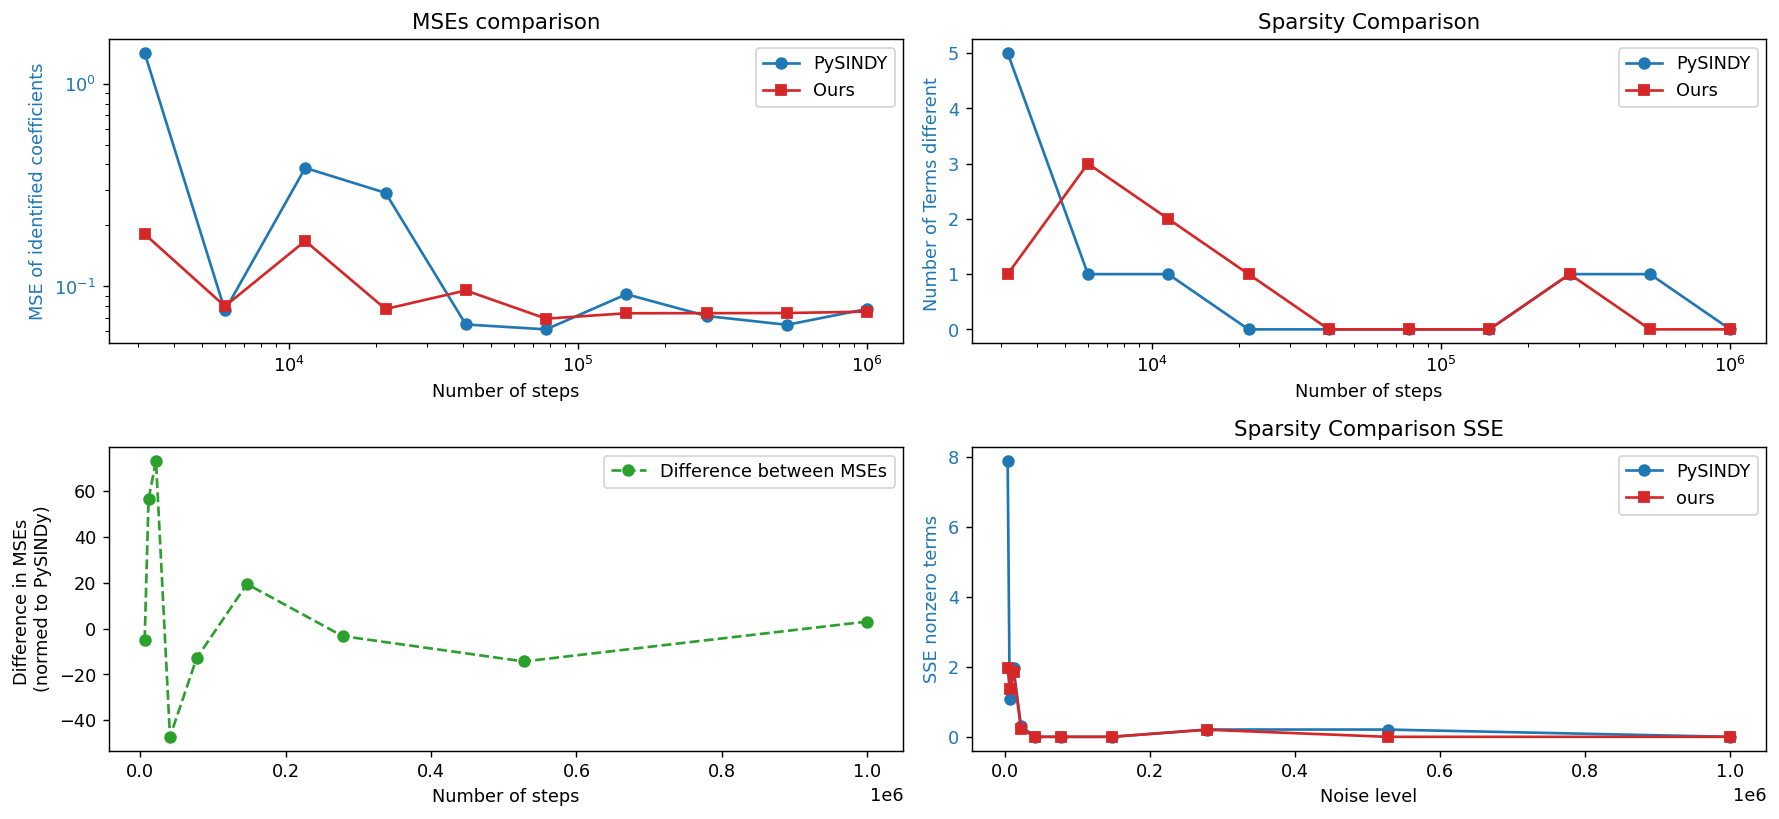

In [17]:

logy = True
logx = True
sparsity = True

# 1. Create a figure with two subplots side-by-side
fig, ((ax_MSEs, ax_sparsity), (ax_diff_MSEs, ax_SSE)) = plt.subplots(2, 2, figsize=(14, 6.5), dpi=128)

MSEs_ours = np.array(MSEs_ours).round(7)
# --- LEFT PLOT: Original SINDy ---
# MSE on left y-axis
ax_MSEs.plot(num_steps_lst, MSEs_pys_steps, marker="o", color="tab:blue", label="PySINDY")
ax_MSEs.plot(num_steps_lst, MSEs_ours_steps, marker="s", color="tab:red", label="Ours")
ax_MSEs.set_xlabel("Number of steps")
ax_MSEs.set_ylabel("MSE of identified coefficients", color="tab:blue")
ax_MSEs.tick_params(axis='y', labelcolor="tab:blue")
ax_MSEs.set_title("MSEs comparison")
if logx:
    ax_MSEs.set_xscale('log')
if logy:
    ax_MSEs.set_yscale('log')
ax_MSEs.legend()

#print(MSEs)
# --- RIGHT PLOT: Our SINDy ---
# MSE on left y-axis
#print(MSEs_ours)
ax_sparsity.plot(num_steps_lst, np.array(term_nums_pys_steps)-7, marker="o", color="tab:blue", label="PySINDY")
ax_sparsity.plot(num_steps_lst, np.array(term_nums_ours_steps)-7, marker="s", color="tab:red", label="Ours")
ax_sparsity.set_xlabel("Number of steps")
ax_sparsity.set_ylabel("Number of Terms different ", color="tab:blue")
ax_sparsity.tick_params(axis='y', labelcolor="tab:blue")
ax_sparsity.set_title("Sparsity Comparison")
if logx:
    ax_sparsity.set_xscale('log')
ax_sparsity.legend()



#Plot difference#
diff = (MSEs_pys_steps - np.array(MSEs_ours_steps).round(7))/MSEs_pys_steps *100
ax_diff_MSEs.plot(num_steps_lst[1:], diff[1:], marker="o", color="tab:green", ls="--", label ="Difference between MSEs")
ax_diff_MSEs.set_ylabel("Difference in MSEs \n(normed to PySINDy)")
ax_diff_MSEs.set_xlabel("Number of steps")
ax_diff_MSEs.legend()


# --- RIGHT PLOT bottom SSE ---
ax_SSE.plot(num_steps_lst, SEs_zterms_pys_steps, marker="o", color="tab:blue", label="PySINDY")
ax_SSE.plot(num_steps_lst, SEs_zterms_ours_steps, marker="s", color="tab:red", label="ours")
#print(SEs_zterms)
#print(SEs_zterms_ours)
ax_SSE.set_xlabel("Noise level")
ax_SSE.set_ylabel("SSE nonzero terms", color="tab:blue")
ax_SSE.tick_params(axis='y', labelcolor="tab:blue")
ax_SSE.set_title("Sparsity Comparison SSE")
ax_SSE.legend()



# 4. Final formatting
fig.tight_layout() 
plt.show()
    #####Plot them

[1.2377141676606886]
[1.2386982]
[np.float64(0.3724403050430241)]
[np.float64(0.4367321124981073)]


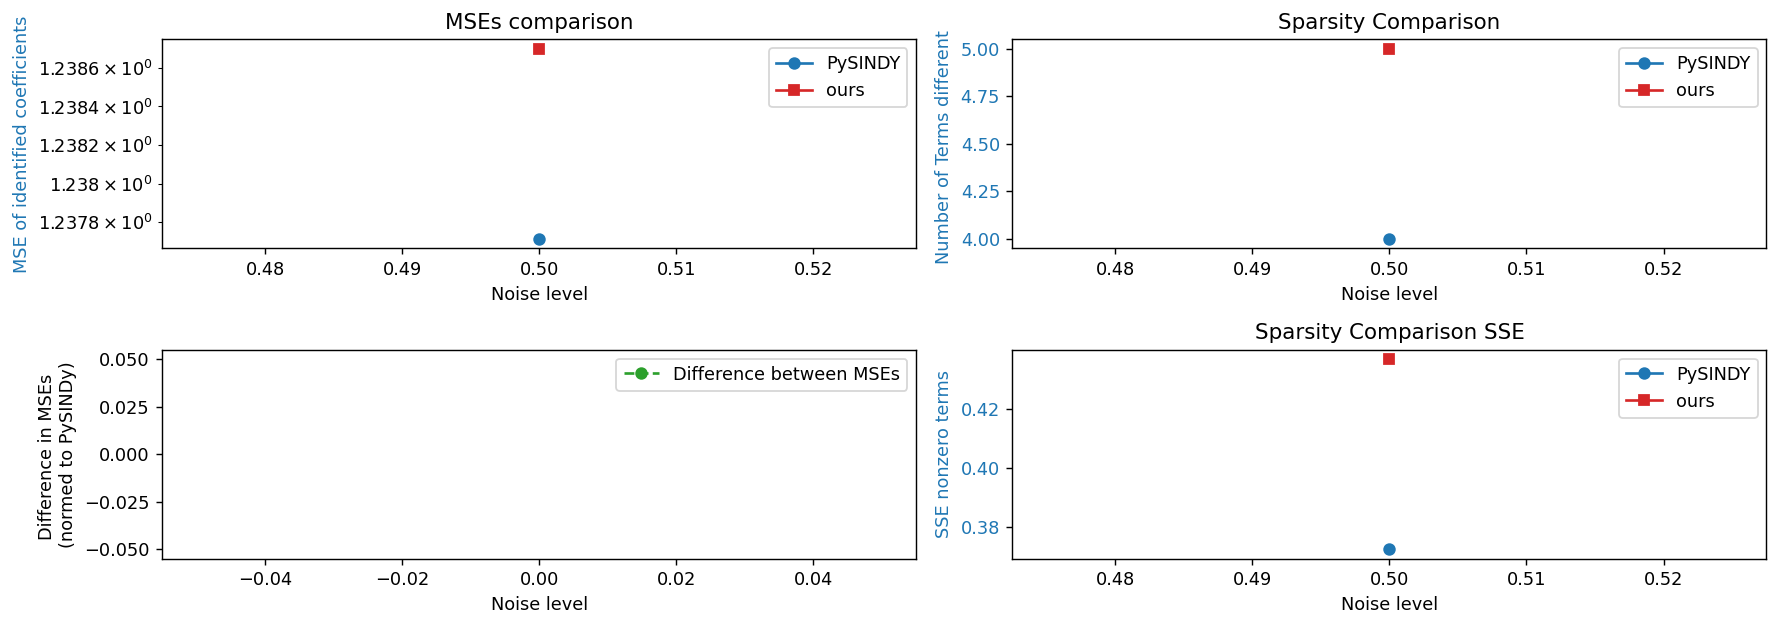

In [12]:
logy = True
logx = False
sparsity = True

# 1. Create a figure with two subplots side-by-side
fig, ((ax_MSEs, ax_sparsity), (ax_diff_MSEs, ax_SSE)) = plt.subplots(2, 2, figsize=(14, 5), dpi=128)

MSEs_ours = np.array(MSEs_ours).round(7)
# --- LEFT PLOT: Original SINDy ---
# MSE on left y-axis
ax_MSEs.plot(noise_levels, MSEs, marker="o", color="tab:blue", label="PySINDY")
ax_MSEs.plot(noise_levels, MSEs_ours, marker="s", color="tab:red", label="ours")
ax_MSEs.set_xlabel("Noise level")
ax_MSEs.set_ylabel("MSE of identified coefficients", color="tab:blue")
ax_MSEs.tick_params(axis='y', labelcolor="tab:blue")
ax_MSEs.set_title("MSEs comparison")
if logx:
    ax_MSEs.set_xscale('log')
if logy:
    ax_MSEs.set_yscale('log')
ax_MSEs.legend()

print(MSEs)
# --- RIGHT PLOT: Our SINDy ---
# MSE on left y-axis
print(MSEs_ours)
ax_sparsity.plot(noise_levels, np.array(term_nums)-7, marker="o", color="tab:blue", label="PySINDY")
ax_sparsity.plot(noise_levels, np.array(term_nums_ours)-7, marker="s", color="tab:red", label="ours")
ax_sparsity.set_xlabel("Noise level")
ax_sparsity.set_ylabel("Number of Terms different ", color="tab:blue")
ax_sparsity.tick_params(axis='y', labelcolor="tab:blue")
ax_sparsity.set_title("Sparsity Comparison")
if logx:
    ax_sparsity.set_xscale('log')
ax_sparsity.legend()



#Plot difference#
diff = (MSEs - np.array(MSEs_ours).round(7))/MSEs *100
ax_diff_MSEs.plot(noise_levels[1:], diff[1:], marker="o", color="tab:green", ls="--", label ="Difference between MSEs")
ax_diff_MSEs.set_ylabel("Difference in MSEs \n(normed to PySINDy)")
ax_diff_MSEs.set_xlabel("Noise level")
ax_diff_MSEs.legend()


# --- RIGHT PLOT bottom SSE ---
ax_SSE.plot(noise_levels, SEs_zterms, marker="o", color="tab:blue", label="PySINDY")
ax_SSE.plot(noise_levels, SEs_zterms_ours, marker="s", color="tab:red", label="ours")
print(SEs_zterms)
print(SEs_zterms_ours)
ax_SSE.set_xlabel("Noise level")
ax_SSE.set_ylabel("SSE nonzero terms", color="tab:blue")
ax_SSE.tick_params(axis='y', labelcolor="tab:blue")
ax_SSE.set_title("Sparsity Comparison SSE")
ax_SSE.legend()



# 4. Final formatting
fig.tight_layout() 
plt.show()

MSE vs Prediction

In [53]:
#Create Xi-
noise_levels = [1] #noise levels to test

#Parameters for the system and data generation
dt = 1e-3
num_steps = 1 * 10 ** 5
x_0 = np.array([0, 2, 8])

threshold = 0.1 # sparsification knob lambda

#Setting up pysindy
sparsity_threshold = threshold
stlsq_optimizer = ps.STLSQ(threshold=sparsity_threshold, alpha=0.05) # alpha can be used for additional regularization

# Initialize the SINDy model with the configured optimizer
model = ps.SINDy(optimizer=stlsq_optimizer)

# Define the polynomial library with degree 3
poly_library = ps.PolynomialLibrary(degree=2)



#Calculate MSE for each noise level using our SINDy
SEs_zterms_ours = []
MSEs_ours = []
XIs_ours = []
for i, noise in enumerate(noise_levels):
    traj = systems.Trajectory(mysindy.lorenz, x_0, dt, num_steps, noise)
    
    #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working
    lib = mysindy.library_function(traj.x_noisy.transpose(), 2, df=False)
    sol = mysindy.stls(lib, traj.x_dot_denoised.transpose(), threshold)
    XIs_ours.append(sol)
    #This is the end of where our sindy implementation differs
    print(f"solve:{sol}")
    print(sol.shape)
    
    lorenz_arr_padded = mysindy.lorenz_array(sol)

    MSEs_ours.append(mean_squared_error(sol, lorenz_arr_padded))

    mask = (sol != 0) & (lorenz_arr_padded == 0)
    SEs_zterms_ours.append(np.sum(np.sqrt((sol[mask]-lorenz_arr_padded[mask])**2)))
term_nums_ours = [np.count_nonzero(xi) for xi in XIs_ours]
print(SEs_zterms_ours)





#Calculate MSE for each noise level using pySINDy
SEs_zterms = []
MSEs = []
XIs = []
for i, noise in enumerate(noise_levels):
    traj = systems.Trajectory(mysindy.lorenz, x_0, dt, num_steps, noise)
    
    #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working
    model_poly3 = ps.SINDy(
      optimizer=stlsq_optimizer,
      feature_library=poly_library
      )
    model_poly3.fit(traj.x_noisy.transpose(), t=dt)
    xi_pys = model_poly3.coefficients()
    XIs.append(xi_pys)
    #This is the end of where our sindy implementation differs
    print(xi_pys.shape)
    
    lorenz_arr_padded = mysindy.lorenz_array(xi.transpose())
    #print(xi.transpose().shape)
    #print(lorenz_arr_padded.shape)
    MSEs.append(mean_squared_error(xi_pys.transpose(), lorenz_arr_padded))

    mask = (xi_pys.transpose() != 0) & (lorenz_arr_padded == 0)
    SEs_zterms.append(np.sum(np.sqrt((xi_pys.transpose()[mask]-lorenz_arr_padded[mask])**2)))


term_nums = [np.count_nonzero(xi) for xi in XIs]
print(SEs_zterms)

Exited at 2 iterations.
solve:[[-0.11261644  0.         -0.76918213]
 [ 0.         19.46177036  0.        ]
 [ 4.2042601   3.8093337   0.        ]
 [ 0.          0.         -2.5654491 ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.97238511]
 [-0.25448613 -0.76346199  0.        ]
 [ 0.          0.          0.        ]
 [ 0.13225817 -0.12550597  0.        ]
 [ 0.          0.          0.        ]]
(10, 3)
[np.float64(1.394048852286769)]
(3, 10)
[np.float64(12.241079745729152)]


In [56]:
#Create an array of different ICs to test the prediction capabilities of the model with different noise levels
ics_list = [np.array([0, 2, 7]), np.array([1, 1, 1]), np.array([-1, -1, -1]), np.array([5, 5, 5]), np.array([-5, -5, -5])]

print (xi)
def get_basis(x_vec):
    x, y, z = x_vec
    # Standard PySINDy polynomial library (order 2)
    return np.array([1, x, y, z, x**2, x*y, x*z, y**2, y*z, z**2])

def sindy_dynamics(t, state, xi_in):
    # Map the current state to the basis
    basis = get_basis(state) 
    return xi_in @ basis

time_eval = 20

for i, noise in enumerate(noise_levels):
    gt_futures = []
    predicted_futures_ours = []
    predicted_futures_pysindy = []
    for j, ics in enumerate(ics_list):
        gt_future_path = mysindy.lorenz_advance(ics, time_eval, dt)
        gt_futures.append(gt_future_path)
        #print(gt_future_path)
        #print (ics)
        
        time_chunks = np.linspace(0, time_eval, len(gt_future_path))
        pred_future_path_ours = np.zeros((len(time_chunks), 3))
        pred_future_path_ours[0,:] = ics
        res_ours = solve_ivp(sindy_dynamics, [0, time_eval], ics, t_eval=time_chunks, args=(sol.T,))
        pred_future_path_ours = res_ours.y.T
        predicted_futures_ours.append(pred_future_path_ours)
        #print(pred_future_path)

        pred_future_path_pysindy = np.zeros((len(time_chunks), 3))
        pred_future_path_pysindy[0,:] = ics
        res_pys = solve_ivp(sindy_dynamics, [0, time_eval], ics, t_eval=time_chunks, args=(xi_pys,))
        pred_future_path_pysindy = res_pys.y.T
        predicted_futures_pysindy.append(pred_future_path_pysindy)


[[ 12.80299826   2.61746679   5.81108876  -0.99903634   0.23696541
   -0.27434565  -0.14062609   0.06826959  -0.1462179    0.        ]
 [ -0.09222237   4.12720232   7.77904038  -0.16681734   0.
    0.05747411  -0.22704839   0.          -0.27177996   0.        ]
 [-22.27095024  -0.59263909   1.50774632  -0.98084931   0.
    0.40266288   0.06222833   0.19060757  -0.08585796   0.        ]]


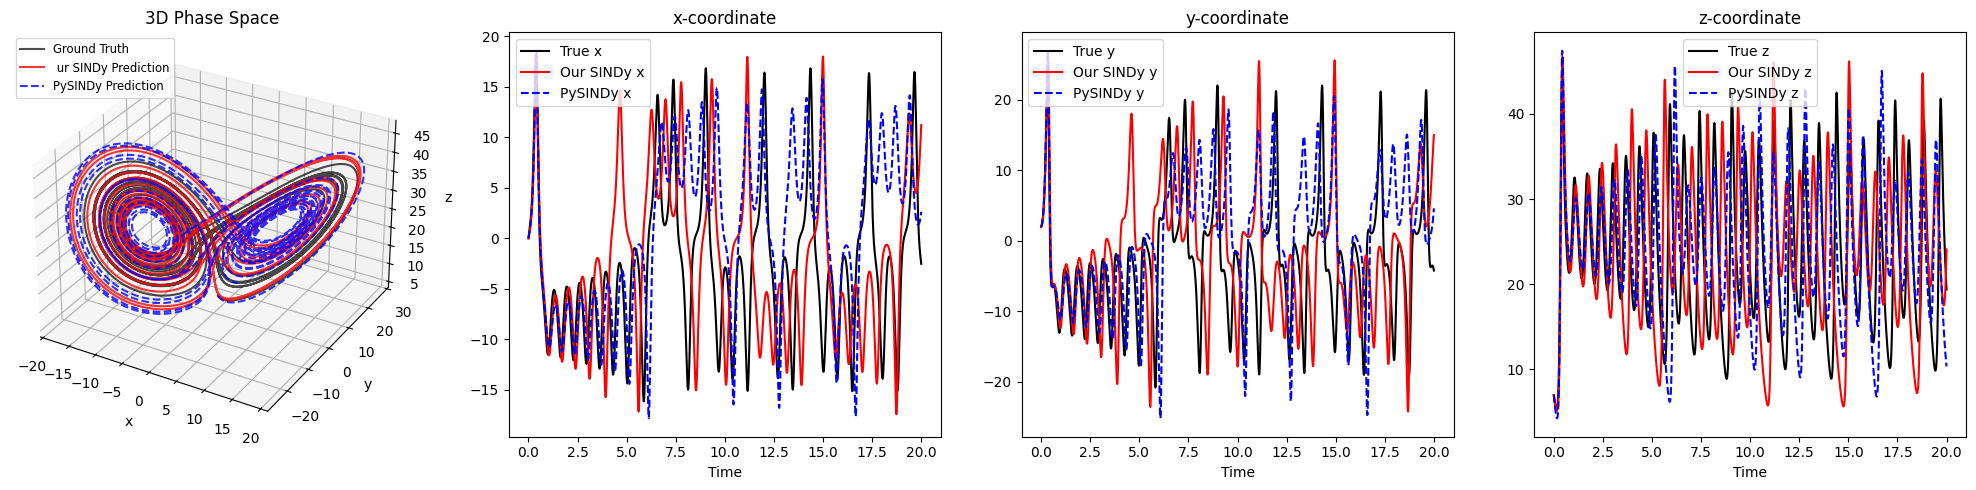

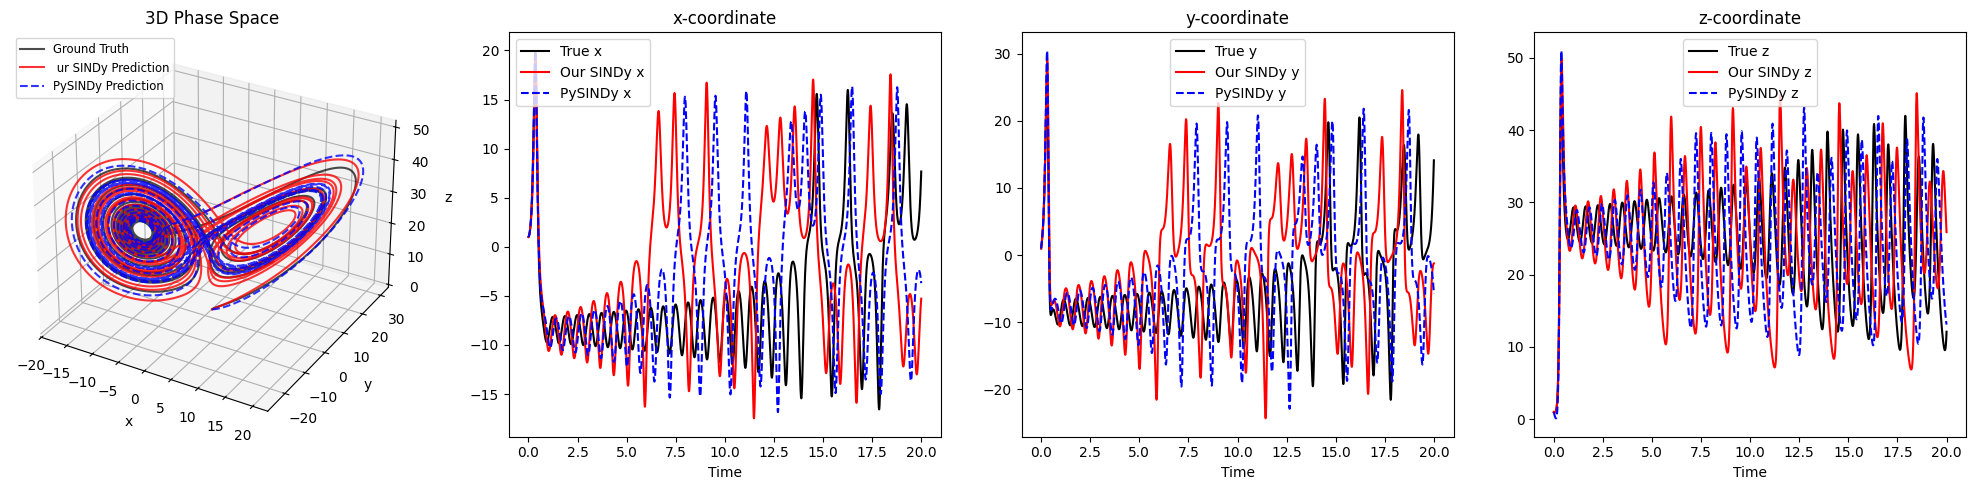

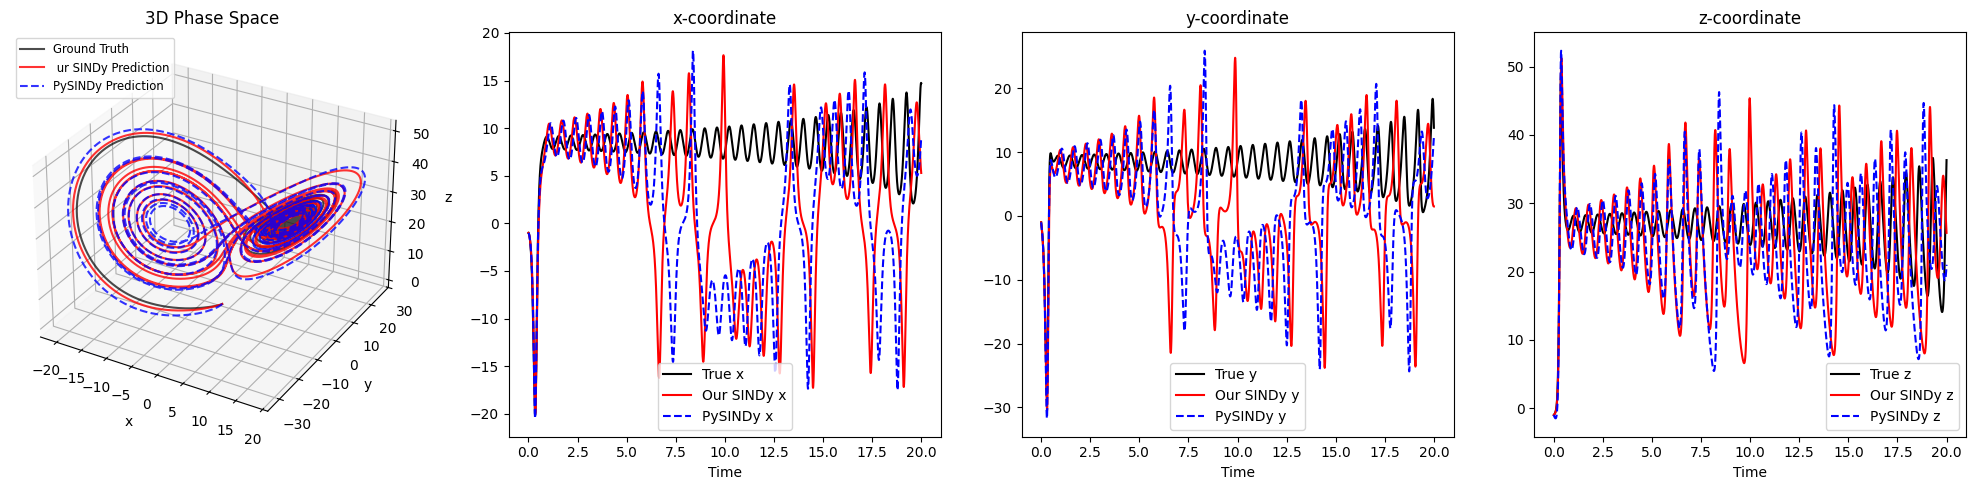

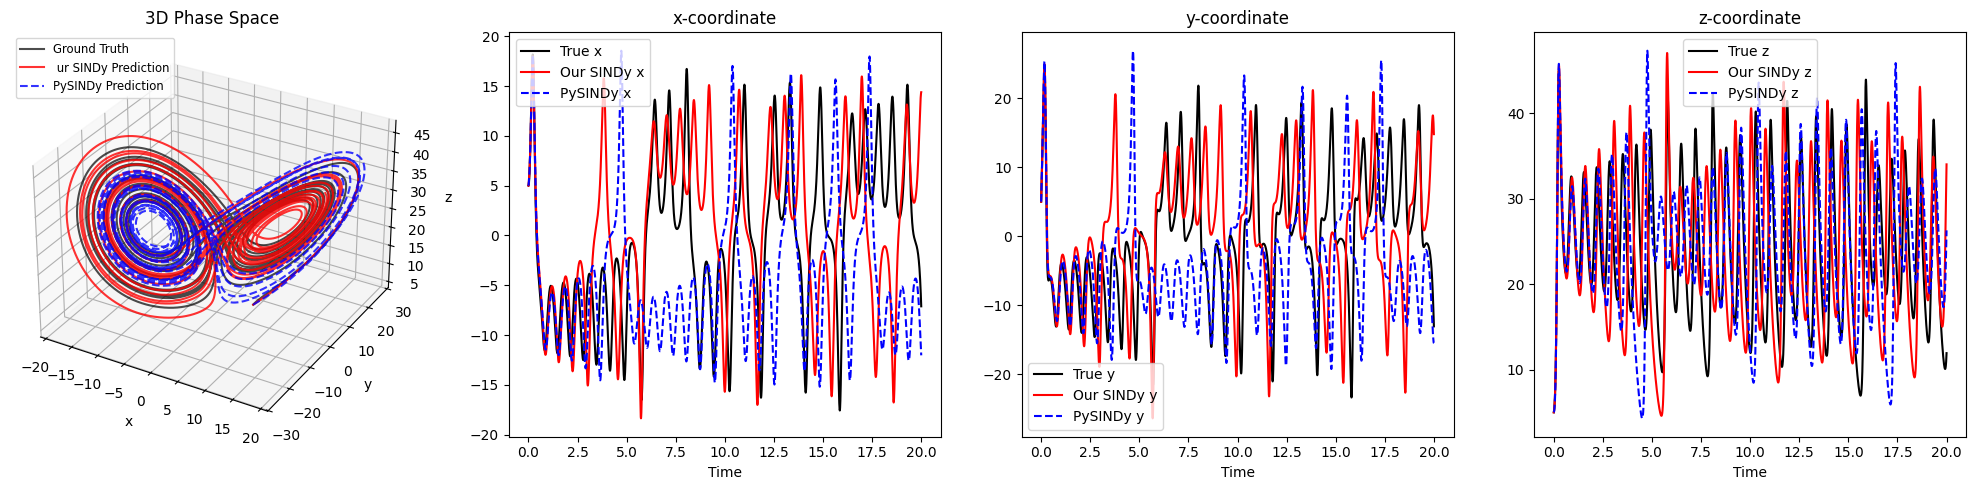

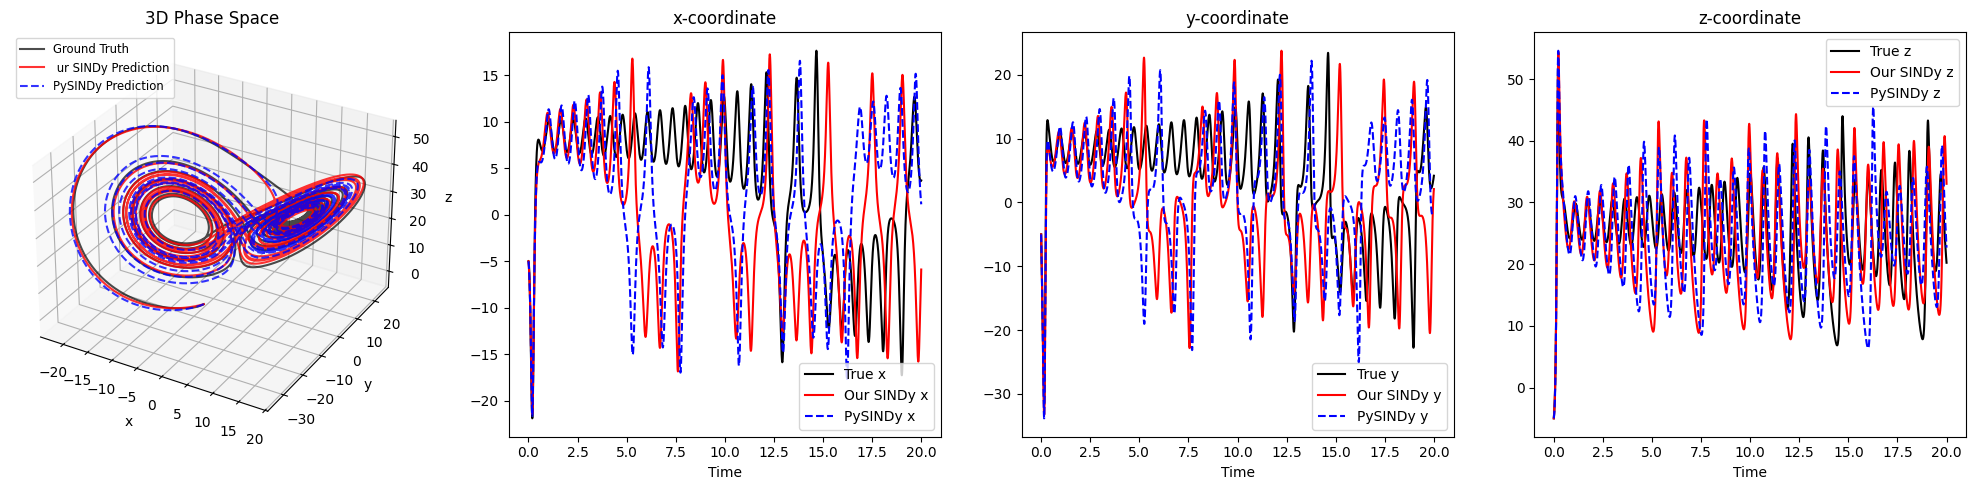

In [57]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
for i in range(len(predicted_futures_ours)):
        gt_future_path = gt_futures[i]
        pred_future_path_ours = predicted_futures_ours[i]
        pred_future_path_pysindy = predicted_futures_pysindy[i]
        

        fig = plt.figure(figsize=(20, 5))

        # 1. Create a 3D Phase Space Comparison (Manually specify 3d projection)
        ax0 = fig.add_subplot(1, 4, 1, projection='3d') 

        # Plotting the 3D Attractor
        ax0.plot(gt_future_path[:, 0], gt_future_path[:, 1], gt_future_path[:, 2], 
                label='Ground Truth', color='black', alpha=0.7)
        ax0.plot(pred_future_path_ours[:, 0], pred_future_path_ours[:, 1], pred_future_path_ours[:, 2], 
                '-', label=' ur SINDy Prediction', color='red', alpha=0.8)
        ax0.plot(pred_future_path_pysindy[:, 0], pred_future_path_pysindy[:, 1], pred_future_path_pysindy[:, 2], 
                '--', label='PySINDy Prediction', color='blue', alpha=0.8)

        ax0.set_title("3D Phase Space")
        ax0.set_xlabel("x")
        ax0.set_ylabel("y")
        ax0.set_zlabel("z")
        # Move legend slightly to avoid overlap
        ax0.legend(loc='upper left', fontsize='small')

        # 2. Plot individual series (These remain 2D)
        labels = ['x', 'y', 'z']
        time_points = np.linspace(0, time_eval, len(gt_future_path))

        for i, label in enumerate(labels):
                # i+2 because subplots are 1-indexed and we want plots 2, 3, and 4
                ax = fig.add_subplot(1, 4, i + 2) 
                ax.plot(time_points, gt_future_path[:, i], 'k-', label=f'True {label}')
                ax.plot(time_points, pred_future_path_ours[:, i], 'r-', label=f'Our SINDy {label}')
                ax.plot(time_points, pred_future_path_pysindy[:, i], 'b--', label=f'PySINDy {label}')
                
                ax.set_title(f"{label}-coordinate")
                ax.set_xlabel("Time")
                ax.legend()

        # Use w_pad to force extra horizontal space between the 3D and 2D plots
        plt.tight_layout(w_pad=3.0)
        plt.show()

Hopf Addtion

In [73]:
#HOPF
noise_levels = [0] #noise levels to test

#Parameters for the system and data generation
dt = 1e-3
num_steps = 1 * 10 ** 4
x_0 = np.array([0, 2, 8])

threshold = 0.01 # sparsification knob lambda

#Setting up pysindy
sparsity_threshold = threshold
stlsq_optimizer = ps.STLSQ(threshold=sparsity_threshold, alpha=0.05) # alpha can be used for additional regularization

# Initialize the SINDy model with the configured optimizer
model = ps.SINDy(optimizer=stlsq_optimizer)

# Define the polynomial library with degree 3
poly_library = ps.PolynomialLibrary(degree=3)



#Calculate MSE for each noise level using our SINDy
SEs_zterms_ours = []
MSEs_ours = []
XIs_ours = []
for i, noise in enumerate(noise_levels):
    hopf = systems.Hopf(x_0, dt, num_steps, noise)
    traj = hopf.traj
    #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working
    lib = mysindy.library_function(traj.x_noisy.transpose(), 3, df=False)
    print(lib.shape)
    with np.printoptions(threshold=sys.maxsize):
        print(hopf.params_array(lib).transpose)
    sol = mysindy.stls(lib, traj.x_dot_denoised.transpose(), threshold)
    XIs_ours.append(sol)
    #This is the end of where our sindy implementation differs
    #print(f"solve:{sol}")
    print(sol.shape)
    
    # lorenz_arr_padded = mysindy.lorenz_array(sol)

    # MSEs_ours.append(mean_squared_error(sol, lorenz_arr_padded))

    # mask = (sol != 0) & (lorenz_arr_padded == 0)
    # SEs_zterms_ours.append(np.sum(np.sqrt((sol[mask]-lorenz_arr_padded[mask])**2)))
term_nums_ours = [np.count_nonzero(xi) for xi in XIs_ours]





#Calculate MSE for each noise level using pySINDy
SEs_zterms = []
MSEs = []
XIs = []
for i, noise in enumerate(noise_levels):
    hopf = systems.Hopf(x_0, dt, num_steps, noise)
    traj = hopf.traj

    #this would be where we apply our own sindy implementation, but for now we'll just use the one from pysindy to make sure everything is working
    model_poly3 = ps.SINDy(
      optimizer=stlsq_optimizer,
      feature_library=poly_library
      )
    model_poly3.fit(traj.x_noisy.transpose(), t=dt)
    xi_pys = model_poly3.coefficients()
    XIs.append(xi_pys)
    #This is the end of where our sindy implementation differs
    #print(f"solve pys:{sol}")
    print(xi_pys.shape)
    
    # lorenz_arr_padded = mysindy.lorenz_array(xi.transpose())
    # #print(xi.transpose().shape)
    # #print(lorenz_arr_padded.shape)
    # MSEs.append(mean_squared_error(xi_pys.transpose(), lorenz_arr_padded))

    # mask = (xi_pys.transpose() != 0) & (lorenz_arr_padded == 0)
    # SEs_zterms.append(np.sum(np.sqrt((xi_pys.transpose()[mask]-lorenz_arr_padded[mask])**2)))


term_nums = [np.count_nonzero(xi) for xi in XIs]

(10001, 20)
<built-in method transpose of numpy.ndarray object at 0x12324aa90>
Exited at 1 iterations.
(20, 3)
(3, 20)


/Users/alexeagan/SINDy/SINDY-Noise-Investigation/.SINDy_venv/lib/python3.14/site-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(
/Users/alexeagan/SINDy/SINDY-Noise-Investigation/.SINDy_venv/lib/python3.14/site-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(
